<a href="https://colab.research.google.com/github/julianeotti/MVP---Machine-Learning-e-Analytics/blob/main/MVP_ML_Analytics_Julia_Neotti_do_Nascimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Júlia Neotti do Nascimento

**Matrícula:** 4052025002490

**Data:** 27/06/2026

**Dataset:** [WHO Life Expectancy](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who/data) + [IDH](https://hdr.undp.org/data-center/documentation-and-downloads)

**Tipo de problema:** Regressão Supervisionada

# 1. Definição do problema

## 1.1 Descrição do problema

A expectativa de vida é um dos principais indicadores utilizados para avaliar o nível de desenvolvimento humano, as condições de saúde e a qualidade de vida de uma população. Esse indicador é influenciado por diversos fatores, incluindo condições econômicas, acesso à educação, desenvolvimento social e indicadores de saúde pública.

Neste trabalho será utilizado um conjunto de dados composto por indicadores socioeconômicos e de saúde de diferentes países, incluindo Índice de Desenvolvimento Humano (IDH), índice de educação, anos médios de escolaridade, Produto Interno Bruto (PIB), taxas de mortalidade e outros indicadores relacionados à saúde da população. Os dados foram obtidos a partir da integração de bases públicas disponibilizadas pela Organização Mundial da Saúde (WHO) e pelo Programa das Nações Unidas para o Desenvolvimento (UNDP).

O problema abordado consiste em prever a expectativa de vida de um país a partir de seus indicadores socioeconômicos e de saúde. A solução proposta pode auxiliar pesquisadores e gestores públicos a compreenderem quais fatores apresentam maior influência sobre a longevidade da população e a estimarem a expectativa de vida em diferentes contextos.

A relevância desse problema está no fato de que a expectativa de vida é amplamente utilizada como indicador de desenvolvimento social e bem-estar. Compreender sua relação com fatores econômicos, educacionais e de saúde pode contribuir para a formulação de estratégias mais eficientes de investimento e planejamento em saúde pública.

A integração das bases foi realizada utilizando a variável País, considerando apenas informações referentes ao ano de 2013. Esse recorte temporal foi adotado para garantir maior consistência entre as fontes de dados, reduzir a presença de valores ausentes e permitir uma análise focada nas relações entre os indicadores, sem a influência de variações temporais.

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> O objetivo deste MVP é construir e avaliar modelos de Machine Learning capazes de prever a expectativa de vida de um país a partir de indicadores socioeconômicos e de saúde, comparando um modelo baseline com diferentes modelos candidatos e analisando seu desempenho, limitações e potencial de aplicação.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão Supervisionada  

**Justificativa:** O problema consiste em prever a expectativa de vida, uma variável numérica contínua expressa em anos. Dessa forma, o objetivo do modelo é estimar um valor quantitativo a partir de um conjunto de variáveis explicativas, caracterizando um problema de regressão. Além disso, trata-se de um problema de aprendizado supervisionado, uma vez que o conjunto de dados contém observações para as quais a variável resposta, a expectativa de vida, é conhecida e utilizada durante o treinamento dos modelos.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Países com melhores indicadores educacionais tendem a apresentar maior expectativa de vida.
2. Altas taxas de mortalidade infantil e mortalidade adulta estão associadas a menores valores de expectativa de vida.
3. Países com maior desenvolvimento econômico, representado pelo PIB per capita, tendem a apresentar maior expectativa de vida.

**Critérios de sucesso:**

- **Métrica principal:** RMSE (Root Mean Squared Error).

- **Métricas complementares:** MAE (Mean Absolute Error) e R² (Coeficiente de Determinação).

- **Resultado mínimo esperado:** obter desempenho superior ao modelo baseline (Dummy Regressor), com redução dos erros de previsão (RMSE e MAE) e coeficiente de determinação (R²) superior a 0,70 no conjunto de teste.

- **Restrições práticas:**

  - Utilizar apenas dados públicos e reproduzíveis.
  - Garantir que o notebook seja executado integralmente no Google Colab.
  - Priorizar modelos com boa capacidade de generalização e interpretação dos resultados.
  - Evitar vazamento de dados durante as etapas de preparação e treinamento.

# 2. Ambiente, bibliotecas e reprodutibilidade

O desenvolvimento deste MVP foi realizado utilizando bibliotecas para manipulação de dados (Pandas e NumPy), visualização (Matplotlib e Seaborn) e modelagem de Machine Learning (Scikit-Learn). Não foi necessária a instalação de dependências adicionais, pois todas as bibliotecas utilizadas já estão disponíveis no ambiente do Google Colab.

Para garantir a reprodutibilidade dos resultados, foi definida uma semente aleatória fixa (seed = 2026). Como o conjunto de dados possui dimensões reduzidas e os modelos adotados apresentam baixo custo computacional, todo o processamento foi realizado em CPU padrão.

In [1]:
# ------ Importação das Bibliotecas

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Reprodutibilidade e configurações gerais
import random
import warnings
import time

# Pré-processamento
from sklearn.model_selection import  train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Busca de hiperparâmetros
from scipy.stats import randint

# Salvamento do modelo final
import joblib

warnings.filterwarnings("ignore")

SEED = 2026
np.random.seed(SEED)
random.seed(SEED)

print("Seed:", SEED)


Seed: 2026


## 2.1 Funções auxiliares

Para melhorar a organização do código e evitar repetições, foram criadas funções auxiliares responsáveis pelo cálculo das métricas de avaliação e pela apresentação dos resultados dos modelos.


In [2]:
# Retorna as métricas de avaliação para regressão.
def calcular_metricas(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R²": r2_score(y_real, y_pred)}

# Converte o dicionário de resultados em DataFrame.
def comparar_modelos(resultados):
    return (pd.DataFrame(resultados).T.sort_values("RMSE"))

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados
Para a construção da base utilizada neste trabalho foram empregados dois conjuntos de dados públicos: o WHO Life Expectancy Dataset, contendo indicadores relacionados à saúde e expectativa de vida, e o Human Development Index (HDI) Dataset, contendo indicadores de desenvolvimento humano, educação e escolaridade.

As bases foram selecionadas por apresentarem informações complementares e potencialmente relevantes para a predição da expectativa de vida, permitindo combinar indicadores econômicos, educacionais e de saúde em um único conjunto de dados.

Como critério de seleção, foram considerados apenas os registros referentes ao ano de 2013, visando aumentar a compatibilidade entre as bases e reduzir a presença de valores ausentes após a integração dos dados.

Por se tratar de bases públicas agregadas por país, não há informações pessoais identificáveis, riscos à privacidade dos indivíduos ou restrições de confidencialidade para utilização dos dados neste projeto.


**Fontes dos dados:**

- WHO Life Expectancy Dataset:
https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who/data
- Human Development Index (HDI) Dataset:
https://hdr.undp.org/data-center/documentation-and-downloads


## 3.2 Carga dos dados

Os dados foram carregados diretamente a partir de  de um repositório público no GitHub, garantindo a reprodutibilidade do projeto e a execução integral do notebook em diferentes ambientes.

In [3]:
#--------- Carga dos Dados

idh_url = "https://raw.githubusercontent.com/julianeotti/MVP---Machine-Learning-e-Analytics/main/IDH.csv"

life_url = "https://raw.githubusercontent.com/julianeotti/MVP---Machine-Learning-e-Analytics/main/WHO_life_expectancy.csv"

idh = pd.read_csv(idh_url, sep=";", decimal=",")
life = pd.read_csv(life_url, sep=";", decimal=",")

print("IDH:", idh.shape)
print("WHO Life Expectancy:", life.shape)

IDH: (5336, 5)
WHO Life Expectancy: (2938, 10)


In [4]:
#---------- Construção da Base Final

idh_2013 = idh[idh["ano"] == 2013].copy()

life_2013 = (life.loc[(life["ano"] == 2013) &(life["status"].notna())].drop(columns=["ano"]).copy())

base2013 = (idh_2013.merge(life_2013,left_on="paises",right_on="pais",how="left").drop(columns=["pais"]))

print("Formato da base final:")
base2013.head()


Formato da base final:


,paises,ano,anos_escolaridade_media,indice_educacao,IDH,status,exp_vida,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
0,Afghanistan,2013,10.2,0.437222,0.484962,Developing,59.9,268.0,66,0.1,0.01,18.1,631.744976
1,Albania,2013,14.8,0.762778,0.781171,Developing,77.2,84.0,0,0.1,4.76,56.5,4414.723140
2,Algeria,2013,14.3,0.693333,0.745817,Developing,75.3,112.0,21,0.1,0.53,57.2,5471.866766
3,Angola,2013,10.3,0.479444,0.547266,Developing,51.1,355.0,69,2.3,8.10,22.1,484.616884
4,Antigua and Barbuda,2013,13.0,0.688889,0.767348,Developing,76.1,133.0,0,0.2,8.58,46.4,12224.864160


## 3.3 Visão geral do dataset

Nesta seção é apresentada uma visão geral da base final construída, incluindo suas dimensões, tipos de dados, presença de valores ausentes e registros duplicados. Essas verificações são importantes para compreender a estrutura do conjunto de dados e identificar possíveis ajustes necessários antes da etapa de modelagem.

In [5]:
# Dimensões da base
print("Linhas e colunas:")
print(base2013.shape)

Linhas e colunas:
(184, 13)


In [6]:
# Tipos de dados
print("\nTipos de dados:")
display(base2013.dtypes.to_frame("Tipo"))


Tipos de dados:


,Tipo
paises,object
ano,int64
anos_escolaridade_media,float64
indice_educacao,float64
IDH,float64
status,object
exp_vida,float64
mortalidade_adulta,float64
mortalidade_infantil,int64
mortalidade_hiv,float64


In [7]:
# Valores ausentes
print("\nValores Ausentes:")
display(base2013.isna().sum().to_frame("Ausentes"))


Valores Ausentes:


,Ausentes
paises,0
ano,0
anos_escolaridade_media,4
indice_educacao,4
IDH,1
status,0
exp_vida,4
mortalidade_adulta,4
mortalidade_infantil,0
mortalidade_hiv,0


In [8]:
# Duplicatas
print("Duplicatas:",base2013.duplicated().sum())

Duplicatas: 0


In [9]:
# Amostra aleatória
display(base2013.sample(5,random_state=SEED))

,paises,ano,anos_escolaridade_media,indice_educacao,IDH,status,exp_vida,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
125,Papua New Guinea,2013,10.1,0.456111,0.521112,Developing,62.4,281.0,10,0.8,0.01,47.2,229.953640
149,Slovenia,2013,17.6,0.911667,0.884251,Developed,85.0,78.0,0,0.1,9.53,58.9,2315.317990
15,Belgium,2013,19.4,0.963333,0.907640,Developed,87.0,77.0,0,0.1,11.77,63.0,4651.386470
65,Greece,2013,16.7,0.845556,0.857923,Developing,86.0,74.0,0,0.1,7.46,65.4,21874.819500
97,Madagascar,2013,10.4,0.516111,0.508954,Developing,64.7,23.0,29,0.4,0.87,19.5,461.723722


A partir das verificações realizadas acima, temos que a base final possui 184 observações e 13 variáveis, distribuídas entre 9 variáveis numéricas contínuas (float64), 2 variáveis numéricas inteiras (int64) e 2 variáveis categóricas (object). Além disso, não foram identificados registros duplicados.

Em relação aos valores ausentes, observa-se que a maioria das variáveis apresenta poucos ou nenhum registro faltante, com destaque para `pib_dolar`, que concentra 27 observações ausentes. Esse aspecto será tratado durante a etapa de preparação dos dados.

A amostra aleatória confirma a presença de países com diferentes níveis de desenvolvimento e perfis de saúde, evidenciando a diversidade e o potencial informativo da base para a construção dos modelos de regressão.

## 3.4 Dicionário de dados

A tabela abaixo apresenta o dicionário de dados da base consolidada, incluindo o tipo, a descrição e o papel de cada variável no processo de modelagem.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| paises | Texto | Nome do país | Não | Identificador, não possui significado preditivo direto |
| ano | Numérica inteira | Ano de referência dos indicadores | Não | Todos os registros são de 2013 |
| IDH | Numérica contínua | Índice de Desenvolvimento Humano | Sim | Indicador de desenvolvimento humano |
| indice_educacao | Numérica contínua | Índice de educação do país | Sim | Relacionado ao nível educacional da população |
| anos_escolaridade_media | Numérica contínua | Média de anos de escolaridade da população | Sim | Indicador educacional |
| pib_dolar | Numérica contínua | Produto Interno Bruto do país | Sim | Indicador econômico |
| mortalidade_adulta | Numérica contínua | Taxa de mortalidade adulta | Sim | Indicador de saúde |
| mortalidade_infantil | Numérica contínua | Taxa de mortalidade infantil | Sim | Indicador de saúde |
| mortalidade_hiv | Numérica contínua | Mortalidade associada ao HIV/AIDS | Sim | Indicador de saúde |
| IMC | Numérica contínua | Índice de Massa Corporal médio | Sim | Indicador de saúde |
| consumo_alcool | Numérica contínua | Consumo médio de álcool per capita | Sim | Indicador comportamental relacionado à saúde |
| status | Categórica | Situação econômica do país (desenvolvido ou em desenvolvimento) | Sim | Necessitará codificação para uso nos modelos |
| exp_vida | Alvo | Expectativa de vida ao nascer | Alvo | Valor a ser previsto pelos modelos de regressão |

As variáveis `paises` e `ano` não serão utilizadas na modelagem. A variável `paises` atua apenas como identificador dos registros, enquanto a variável `ano` não apresenta variabilidade, uma vez que todos os dados se referem ao ano de 2013. A variável `exp_vida` será utilizada como variável-alvo, enquanto as demais comporão o conjunto de atributos preditores dos modelos de Machine Learning.

# 4. Análise exploratória dos dados

Nesta seção será realizada uma análise exploratória dos dados para compreender o comportamento da variável-alvo e dos principais atributos preditores. Serão investigadas distribuições, correlações, valores ausentes e possíveis outliers, com o objetivo de identificar padrões relevantes e orientar as etapas de pré-processamento e modelagem.

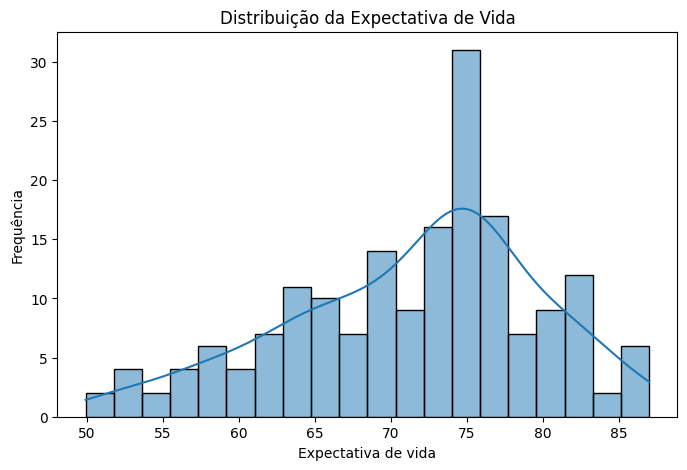

In [10]:
#-------------- Distribuição da variável-alvo

plt.figure(figsize=(8,5))

sns.histplot(base2013["exp_vida"],bins=20,kde=True)

plt.title("Distribuição da Expectativa de Vida")
plt.xlabel("Expectativa de vida")
plt.ylabel("Frequência")

plt.show()

Observa-se que a variável `exp_vida` apresenta distribuição relativamente concentrada entre valores intermediários e elevados, principalmente entre 65 e 85 anos, com poucos países apresentando expectativas de vida muito baixas. Essa distribuição sugere a presença de diferenças importantes entre os países analisados, o que pode favorecer a capacidade preditiva dos modelos de regressão.


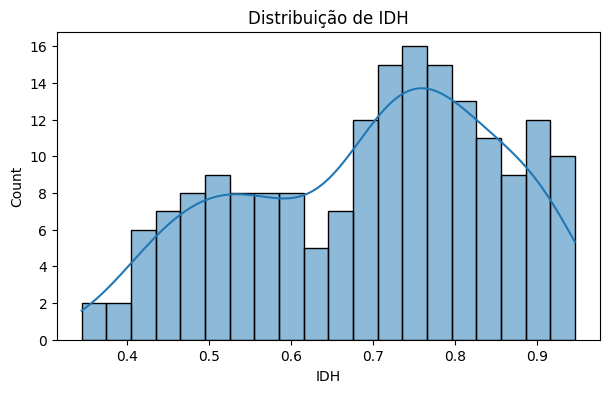

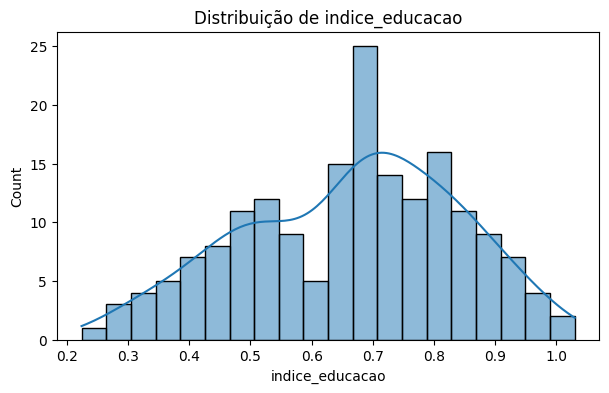

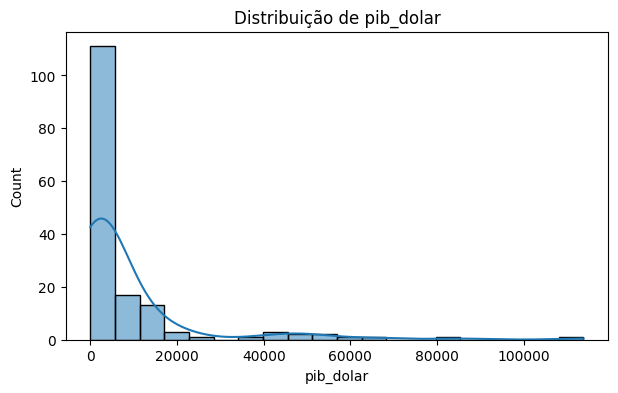

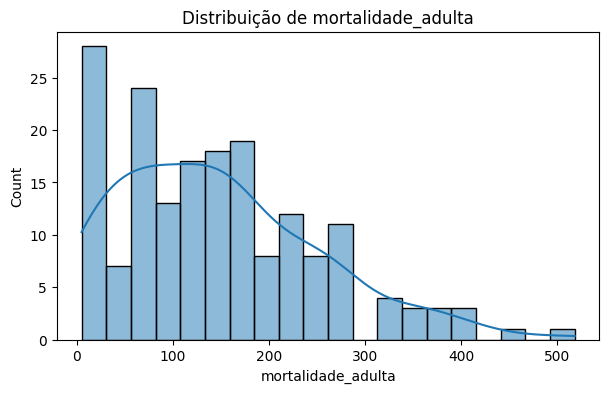

In [11]:
#-------------- Distribuição das variáveis numéricas

variaveis = ["IDH","indice_educacao","pib_dolar","mortalidade_adulta"]

for var in variaveis:

    plt.figure(figsize=(7,4))

    sns.histplot(base2013[var],bins=20,kde=True)

    plt.title(f"Distribuição de {var}")
    plt.xlabel(var)

    plt.show()

Os gráficos mostram comportamentos distintos entre as variáveis analisadas. Indicadores como IDH e indice_educacao apresentam distribuições mais concentradas, enquanto variáveis como pib_dolar e mortalidade_adulta apresentam maior dispersão e presença de valores extremos.

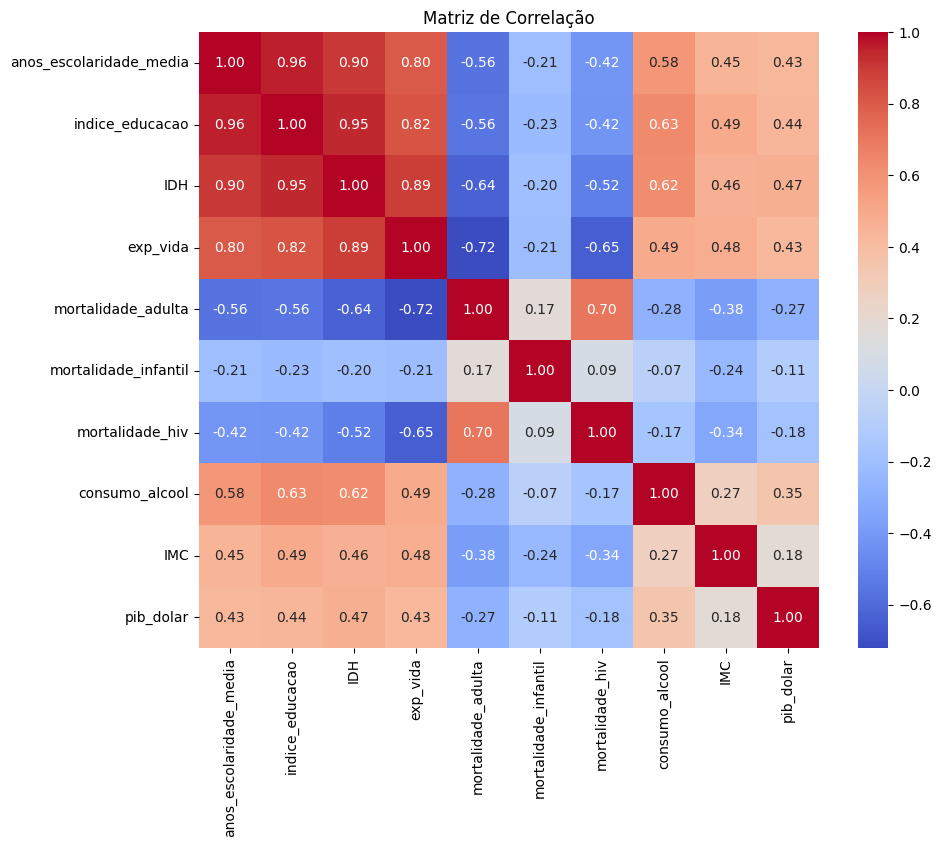

In [12]:
#-------------- Matriz de correlação

plt.figure(figsize=(10,8))

correlacao = (base2013.drop(columns=["ano"]).corr(numeric_only=True))

sns.heatmap(correlacao,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Matriz de Correlação")

plt.show()

A matriz de correlação indica que IDH (0,89), indice_educacao (0,82) e anos_escolaridade_media (0,80) apresentam forte correlação positiva com a expectativa de vida. Em contrapartida, mortalidade_adulta (-0,72) e mortalidade_hiv (-0,65) apresentam correlação negativa relevante.

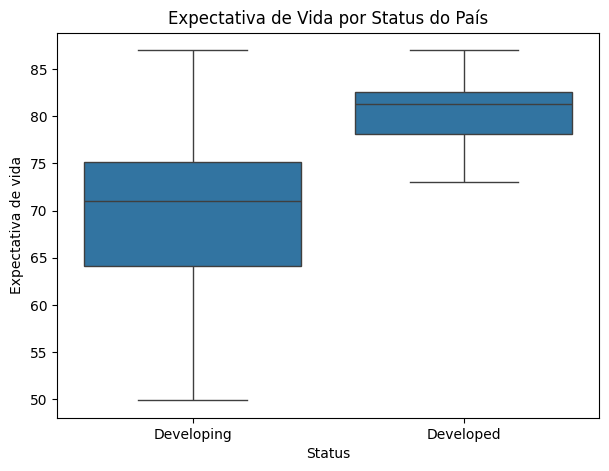

In [13]:
#-------------- Boxplot da expectativa de vida por status

plt.figure(figsize=(7,5))

sns.boxplot(data=base2013,x="status",y="exp_vida")

plt.title("Expectativa de Vida por Status do País")
plt.xlabel("Status")
plt.ylabel("Expectativa de vida")

plt.show()

O boxplot evidencia diferenças relevantes entre países desenvolvidos e em desenvolvimento. Em média, países classificados como desenvolvidos apresentam maiores valores de expectativa de vida, além de menor dispersão dos dados. Também é possível observar a presença de alguns valores extremos, característica comum em bases reais envolvendo indicadores socioeconômicos e de saúde.

## 4.1 Síntese da análise exploratória

**Síntese:**  

A análise exploratória mostrou que a variável-alvo `exp_vida` apresenta distribuição adequada para um problema de regressão, com boa variabilidade entre os países e sem concentrações excessivas em faixas específicas de valores.

Também foram identificados valores ausentes em algumas variáveis, principalmente em `pib_dolar`, indicando a necessidade de tratamento durante o pré-processamento. Além disso, observou-se que algumas variáveis apresentam escalas bastante distintas, especialmente `pib_dolar`, o que sugere a utilização de técnicas de padronização antes do treinamento de determinados modelos.

A matriz de correlação indicou forte associação positiva entre a expectativa de vida e indicadores de desenvolvimento humano e educação, como `IDH`, `indice_educacao` e `anos_escolaridade_media`, além de correlação negativa com indicadores de mortalidade. Esses resultados reforçam as hipóteses inicialmente definidas para o problema.

Por fim, foram identificados possíveis valores extremos em variáveis como `pib_dolar` e `mortalidade_adulta`, o que motivou a inclusão de uma etapa específica de tratamento de outliers na preparação dos dados. Dessa forma, os resultados da análise exploratória contribuíram diretamente para a definição das estratégias de pré-processamento que serão aplicadas antes da construção dos modelos de Machine Learning.



# 5. Preparação dos dados e divisão treino/teste

Para a construção dos modelos, foram utilizadas as variáveis preditoras da base final, excluindo-se as colunas paises e ano, que não contribuem para a predição da expectativa de vida. Dessa forma, o conjunto de dados utilizado na modelagem é composto apenas por atributos com potencial explicativo para a variável-alvo.

Além disso, antes da separação entre atributos e variável-alvo, foram removidos os registros com valores ausentes em exp_vida, uma vez que modelos supervisionados de regressão exigem que a variável-alvo esteja disponível durante o treinamento.

In [14]:
#---------- Configuração do problema

# Definição das variáveis
TARGET = "exp_vida"
PROBLEM_TYPE = "regressao"
DROP_COLUMNS = ["paises", "ano"]

# Remoção de registros sem valor da variável-alvo
base_modelagem = base2013.dropna(subset=[TARGET]).copy()

# Seleção das variáveis preditoras
features = [
    c for c in base_modelagem.columns
    if c not in DROP_COLUMNS + [TARGET]
]

# Construção da matriz de atributos (X)
# As colunas 'paises' e 'ano' são removidas por não contribuírem para a capacidade preditiva do modelo
X = base_modelagem[features].copy()

# Construção do vetor alvo (y)
y = base_modelagem[TARGET].copy()

# Verificação da estrutura dos dados que serão utilizados na modelagem
print("Variável-alvo:", TARGET)
print("Número de atributos preditores:", len(features))
print("Registros utilizados na modelagem:", base_modelagem.shape[0])

# Visualização das primeiras observações das variáveis preditoras
display(X.head())

Variável-alvo: exp_vida
Número de atributos preditores: 10
Registros utilizados na modelagem: 180


,anos_escolaridade_media,indice_educacao,IDH,status,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
0,10.2,0.437222,0.484962,Developing,268.0,66,0.1,0.01,18.1,631.744976
1,14.8,0.762778,0.781171,Developing,84.0,0,0.1,4.76,56.5,4414.723140
2,14.3,0.693333,0.745817,Developing,112.0,21,0.1,0.53,57.2,5471.866766
3,10.3,0.479444,0.547266,Developing,355.0,69,2.3,8.10,22.1,484.616884
4,13.0,0.688889,0.767348,Developing,133.0,0,0.2,8.58,46.4,12224.864160


In [15]:
#------------ Divisão dos dados

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=SEED)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (144, 10)
Teste : (36, 10)


## 5.1 Justificativa da divisão

Foi utilizada a estratégia de holdout, com separação de 80% dos dados para treinamento e 20% para teste. Essa abordagem é amplamente utilizada em problemas de regressão e é adequada para o tamanho da base utilizada neste estudo.

Como o conjunto de dados não possui estrutura temporal e o objetivo é avaliar a capacidade de generalização dos modelos para observações não vistas durante o treinamento, a divisão aleatória dos registros é suficiente. Além disso, a utilização de uma semente fixa garante a reprodutibilidade dos resultados.

A variável-alvo foi removida do conjunto de atributos preditores antes da divisão dos dados, evitando vazamento de informação entre as etapas de treinamento e avaliação dos modelos.


# 6. Pré-processamento e pipeline

Nesta etapa são realizados os tratamentos necessários para preparar os dados para a modelagem. Com base na análise exploratória, foram identificados valores ausentes, possíveis outliers, uma variável categórica e atributos altamente correlacionados. Dessa forma, serão aplicadas etapas de seleção de atributos, tratamento de valores faltantes, codificação de variáveis categóricas e padronização dos dados, utilizando uma abordagem reprodutível por meio de pipelines.


## 6.1 Seleção de atributos

A análise de correlação realizada na etapa exploratória indicou forte associação entre as variáveis `IDH`, `indice_educacao` e `anos_escolaridade_media`. Como essas variáveis representam aspectos semelhantes do desenvolvimento humano e da educação, optou-se por remover `IDH` e `anos_escolaridade_media`, mantendo apenas `indice_educacao`.

In [16]:
#----------- Remoção de variáveis altamente correlacionadas

X_train = X_train.drop(columns=["IDH", "anos_escolaridade_media"])

X_test = X_test.drop(columns=["IDH", "anos_escolaridade_media"])

print("Variáveis após seleção:")
display(X_train.head())

Variáveis após seleção:


,indice_educacao,status,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
92,0.526667,Developing,518.0,4,9.6,0.01,31.4,1196.133500
183,0.562222,Developing,399.0,25,6.8,6.39,3.8,111.227396
18,0.481111,Developing,219.0,0,0.6,0.01,22.7,235.882889
151,0.711667,Developing,371.0,43,4.5,7.34,49.5,6876.953821
136,0.482222,Developing,233.0,12,0.5,0.01,2.1,688.876856


## 6.2 Identificação das variáveis numéricas e categóricas

Após a seleção dos atributos, as variáveis foram separadas em numéricas e categóricas para permitir a aplicação de tratamentos específicos durante o pré-processamento. As variáveis numéricas receberão imputação e padronização, enquanto a variável categórica será codificada para utilização pelos algoritmos de Machine Learning.


In [17]:
#--------- Identificação das variáveis

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Variáveis numéricas:")
print(num_cols)

print("\nVariáveis categóricas:")
print(cat_cols)

Variáveis numéricas:
['indice_educacao', 'mortalidade_adulta', 'mortalidade_infantil', 'mortalidade_hiv', 'consumo_alcool', 'IMC', 'pib_dolar']

Variáveis categóricas:
['status']


## 6.3 Construção do pipeline de pré-processamento

Para garantir a reprodutibilidade do processo e evitar vazamento de informação, foi utilizado um pipeline de pré-processamento. Nas variáveis numéricas, os valores ausentes foram preenchidos pela mediana e posteriormente os dados foram padronizados por meio do StandardScaler. Para a variável categórica `status`, os valores ausentes foram substituídos pela categoria mais frequente e a codificação foi realizada utilizando One-Hot Encoding.


In [18]:
#--------------- Pipeline de pré-processamento

# Pipeline para variáveis numéricas
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variáveis categóricas
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pipeline completo
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("Pipeline criado com sucesso.")

Pipeline criado com sucesso.


## 6.4 Decisões de pré-processamento

A mediana foi escolhida para a imputação das variáveis numéricas por ser menos sensível à presença de valores extremos. Para a variável categórica, foi utilizada a categoria mais frequente, preservando a distribuição original dos dados.

A variável `status` foi transformada por meio de One-Hot Encoding para que pudesse ser utilizada pelos modelos de Machine Learning, mantendo a distinção entre países desenvolvidos e em desenvolvimento. Além disso, as variáveis numéricas foram padronizadas utilizando o StandardScaler, para reduzir as diferenças de escala entre os atributos.

A remoção das variáveis `IDH` e `anos_escolaridade_media`, foi realizada com o objetivo de reduzir a multicolinearidade entre os atributos preditores e simplificar a modelagem, preservando as informações relevantes para a previsão da expectativa de vida.

Todas as transformações foram definidas utilizando apenas os dados de treinamento e posteriormente aplicadas ao conjunto de teste por meio do pipeline, evitando vazamento de informação durante o processo de modelagem.


# 7. Baseline e modelos candidatos

Nesta etapa serão apresentados os modelos utilizados no processo de previsão da expectativa de vida, incluindo um modelo baseline e dois modelos candidatos para comparação de desempenho.


In [19]:
#------------ Baseline e modelos candidatos

# Modelo baseline
baseline = Pipeline([("preprocess", preprocess),("model", DummyRegressor(strategy="mean"))])

# Modelos candidatos
candidates = {

    "Ridge": Pipeline([("preprocess", preprocess),("model", Ridge())]),
    "RandomForestRegressor": Pipeline([("preprocess", preprocess),("model", RandomForestRegressor(random_state=SEED))])}

print("Modelo baseline: DummyRegressor")
print("Modelos candidatos:", list(candidates.keys()))


Modelo baseline: DummyRegressor
Modelos candidatos: ['Ridge', 'RandomForestRegressor']


## 7.1 Justificativa dos modelos

O DummyRegressor foi utilizado como modelo baseline por realizar previsões utilizando apenas a média da variável-alvo. Seu objetivo é servir como referência inicial para verificar se os modelos de Machine Learning conseguem obter resultados superiores aos de uma estratégia simples.

Como primeiro modelo candidato, foi escolhida a Regressão Ridge, por ser um modelo amplamente utilizado em problemas de regressão e adequado para bases com quantidade reduzida de observações. Além disso, esse modelo se beneficia da padronização dos atributos realizada na etapa de pré-processamento.

O segundo modelo selecionado foi o Random Forest Regressor, que utiliza múltiplas árvores de decisão para realizar as previsões. Esse modelo possui maior flexibilidade para capturar padrões mais complexos nos dados e costuma apresentar bom desempenho em problemas de regressão.

A comparação entre esses modelos permite avaliar diferentes abordagens para o problema, identificando qual delas apresenta melhor capacidade preditiva para a base utilizada. Como o conjunto de dados possui tamanho reduzido, o treinamento dos modelos apresenta baixo custo computacional e tempo de execução adequado para os objetivos deste MVP.



# 8. Treinamento e avaliação inicial

Nesta etapa são treinados o modelo baseline e os modelos candidatos definidos anteriormente. O objetivo é comparar o desempenho inicial das diferentes abordagens por meio das métricas de regressão selecionadas, verificando sua capacidade de prever a expectativa de vida a partir dos indicadores socioeconômicos e de saúde presentes na base.



In [20]:
#------------ Treinamento e avaliação inicial

resultados = {}

# Baseline
baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_test)

# Cálculo das métricas (utilizando a função auxiliar calcular_metricas() criada na seção 2.1)
resultados["Baseline"] = calcular_metricas(y_test,pred_baseline)

# Modelos candidatos
for nome, modelo in candidates.items():

    modelo.fit(X_train, y_train)

    predicoes = modelo.predict(X_test)

    resultados[nome] = calcular_metricas(y_test,predicoes)

# Comparação dos modelos (utilizando a função auxiliar comparar_modelos() criada na seção 2.1)
comparar_modelos(resultados)

,MAE,RMSE,R²
RandomForestRegressor,2.716639,3.454930,0.825181
Ridge,3.423787,4.000642,0.765594
Baseline,7.255208,8.910922,-0.162933


## 8.1 Análise dos resultados iniciais

Os resultados obtidos mostram que ambos os modelos de Machine Learning apresentaram desempenho superior ao modelo baseline. Enquanto o DummyRegressor apresentou um R² negativo (-0,16) e os maiores erros de previsão (MAE = 7,26 e RMSE = 8,91), os modelos treinados com os indicadores socioeconômicos e de saúde conseguiram capturar relações relevantes presentes nos dados.

A Regressão Ridge apresentou um bom desempenho inicial, alcançando R² de 0,77. Isso indica que uma parcela significativa da variação da expectativa de vida pode ser explicada pelas variáveis utilizadas no modelo. Além disso, os valores de MAE e RMSE foram consideravelmente menores quando comparados ao baseline.

O melhor resultado foi obtido pelo Random Forest Regressor que apresentou os menores erros de previsão (MAE = 2,72 e RMSE = 3,45) e o maior coeficiente de determinação (R² = 0,83). Esse resultado sugere que existem relações mais complexas entre os indicadores analisados e a expectativa de vida, que podem ser melhor capturadas por um modelo baseado em árvores de decisão.

De modo geral, os resultados são coerentes com a análise exploratória realizada anteriormente, que apontou associações importantes entre expectativa de vida, educação e indicadores de mortalidade. Além disso, todos os modelos avaliados superaram o baseline e apresentaram valores de R² superiores ao limite definido para este MVP (0,70), indicando boa capacidade preditiva para a base estudada.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa foi realizada uma busca simples de hiperparâmetros para o Random Forest Regressor, modelo que apresentou o melhor desempenho na avaliação inicial. O objetivo foi verificar se pequenos ajustes na configuração do modelo poderiam melhorar sua capacidade preditiva, utilizando validação cruzada no conjunto de treinamento.



In [22]:
#-------------- Validação e otimização de hiperparâmetros

# Estratégia de validação cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Modelo selecionado para otimização
modelo_otimizado = Pipeline([("preprocess", preprocess), ("model", RandomForestRegressor(random_state=SEED))])

# Definição do espaço de busca dos hiperparâmetros
parametros = {
    "model__n_estimators": randint(50, 250),
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 10)
}

# Busca aleatória de hiperparâmetros
search = RandomizedSearchCV(
    estimator=modelo_otimizado,
    param_distributions=parametros,
    n_iter=5,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=1
)

# Treinamento da busca no conjunto de treino
search.fit(X_train, y_train)

print("Melhor RMSE médio na validação cruzada:", -search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)

Melhor RMSE médio na validação cruzada: 3.042247990487053
Melhores hiperparâmetros: {'model__max_depth': 7, 'model__min_samples_split': 6, 'model__n_estimators': 78}


## 9.1 Discussão da otimização

A otimização foi realizada utilizando o Random Forest Regressor, modelo que apresentou o melhor desempenho na etapa inicial de avaliação. Para a busca dos hiperparâmetros foi utilizada validação cruzada do tipo K-Fold com 5 partições, tendo o RMSE como métrica de referência.

A melhor configuração encontrada foi composta por 78 árvores de decisão (*n_estimators* = 78), profundidade máxima de 7 níveis (*max_depth* = 7) e mínimo de 6 observações para divisão dos nós (*min_samples_split* = 6). Com essa configuração, o modelo alcançou RMSE médio de 3,04 durante a validação cruzada.

Os hiperparâmetros selecionados resultaram em um modelo com complexidade moderada, evitando árvores excessivamente profundas e reduzindo o risco de sobreajuste. Além disso, a busca permitiu identificar uma configuração com bom desempenho durante a validação cruzada. A confirmação dos ganhos em relação à configuração inicial foi realizada posteriormente na avaliação final do conjunto de teste.

A busca foi limitada a 5 combinações aleatórias dos hiperparâmetros avaliados, o que se mostrou suficiente para identificar uma boa configuração do modelo. Em trabalhos futuros, poderiam ser explorados intervalos maiores para *n_estimators* e *max_depth*, bem como outros hiperparâmetros do Random Forest, como *min_samples_leaf* e *max_features*, para verificar possíveis ganhos adicionais de desempenho.

# 10. Avaliação final do modelo

Após a etapa de otimização dos hiperparâmetros, o modelo selecionado foi avaliado utilizando o conjunto de teste. Como esses dados não participaram do treinamento nem da otimização do modelo, essa etapa permite verificar seu desempenho em observações não vistas anteriormente.

In [23]:
#--------------- Avaliação final do modelo

# Utilizando o melhor modelo encontrado na otimização
modelo_final = search.best_estimator_

# Previsões no conjunto de teste
pred_final = modelo_final.predict(X_test)

# Métricas finais
metricas_finais = calcular_metricas(y_test,pred_final)

pd.DataFrame(metricas_finais,index=["Random Forest Otimizado"])

,MAE,RMSE,R²
Random Forest Otimizado,2.700751,3.449523,0.825728


In [24]:
#-------------- Comparação entre baseline e modelo final

comparacao_final = pd.DataFrame({"Baseline": resultados["Baseline"],"Modelo Final": metricas_finais})

comparacao_final

,Baseline,Modelo Final
MAE,7.255208,2.700751
RMSE,8.910922,3.449523
R²,-0.162933,0.825728


O modelo final apresentou desempenho superior ao baseline em todas as métricas avaliadas. O RMSE foi reduzido de 8,91 para 3,45, o MAE de 7,26 para 2,70 indicando previsões significativamente mais próximas dos valores reais. Além disso, o R² passou de -0,16 para 0,83, o que indica que o modelo foi capaz de explicar aproximadamente 83% da variação observada na expectativa de vida a partir dos indicadores utilizados, demonstrando boa capacidade preditiva para a base analisada.

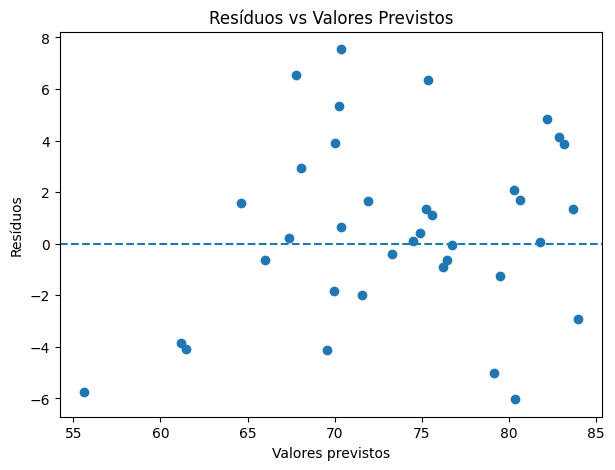

In [25]:
#--------------- Resíduos do modelo final

residuos = y_test - pred_final

plt.figure(figsize=(7,5))

plt.scatter(pred_final, residuos)

plt.axhline(y=0,linestyle="--")

plt.title("Resíduos vs Valores Previstos")
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")

plt.show()

De modo geral, os resíduos ficaram distribuídos próximos da linha zero, indicando que o modelo conseguiu realizar previsões próximas dos valores reais para a maior parte dos países da base. Embora existam alguns erros mais elevados, não foi observado nenhum padrão que sugira problemas importantes no ajuste do modelo.

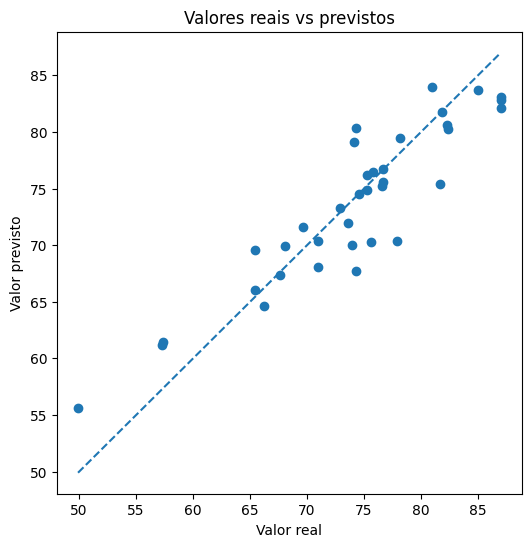

In [26]:
#------------------ Valores Reais vs Valores Previstos

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_final)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],"--")

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Valores reais vs previstos")

plt.show()

O gráfico de valores reais versus previstos mostra boa concordância entre as previsões do modelo e os valores observados. A maior parte dos pontos encontra-se próxima da linha de referência, indicando que as estimativas produzidas pelo modelo ficaram próximas dos valores reais para a maioria dos países analisados. Esse resultado está de acordo com o desempenho observado nas métricas de avaliação, especialmente o valor de R² obtido.

Além da avaliação por métricas de desempenho, foi analisada a importância relativa das variáveis utilizadas pelo modelo. Essa análise permite identificar quais atributos contribuíram mais para a previsão da expectativa de vida e verificar se os resultados obtidos são compatíveis com os padrões observados durante a análise exploratória.

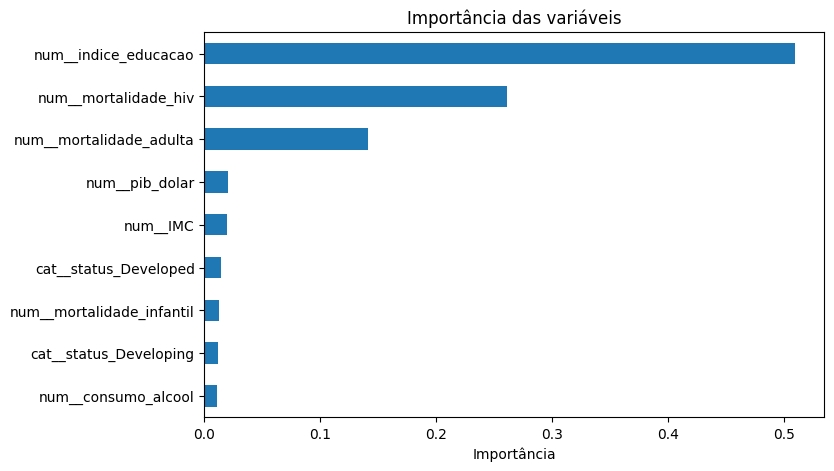

In [27]:
#-------------- Importância das variáveis

modelo_rf = search.best_estimator_.named_steps["model"]

# Recuperação dos nomes das variáveis após o pré-processamento
feature_names = (search.best_estimator_.named_steps["preprocess"].get_feature_names_out())

importancias = pd.Series(modelo_rf.feature_importances_,index=feature_names).sort_values(ascending=False)

# Visualização das 10 variáveis mais importantes
plt.figure(figsize=(8,5))

importancias.head(10).sort_values().plot(kind="barh")

plt.title("Importância das variáveis")
plt.xlabel("Importância")

plt.show()

A análise de importância das variáveis mostrou que o índice de educação foi o atributo com maior contribuição para as previsões do modelo, seguido pelos indicadores de mortalidade associada ao HIV/AIDS e mortalidade adulta. Esses resultados são consistentes com a análise exploratória, que já indicava forte relação entre educação, mortalidade e expectativa de vida. Além disso, a relevância do índice de educação reforça a decisão de mantê-lo na modelagem após a remoção de variáveis altamente correlacionadas, como IDH e anos médios de escolaridade.

## 10.1 Análise de erros e limitações

De forma geral, o modelo apresentou bom desempenho na previsão da expectativa de vida, com resultados consistentes tanto na validação cruzada quanto no conjunto de teste. Os erros observados foram relativamente baixos e não indicam problemas importantes de ajuste aos dados. Além disso, a boa concordância entre os valores reais e previstos observada nos gráficos reforça a capacidade do modelo de representar os padrões presentes na base analisada.

Também não foram observados sinais claros de underfitting, já que o modelo conseguiu explicar grande parte da variabilidade da variável-alvo. Da mesma forma, o uso de validação cruzada durante a etapa de otimização contribuiu para reduzir o risco de overfitting.

As métricas utilizadas mostraram-se adequadas ao objetivo do problema. O RMSE foi adotado como métrica principal por penalizar erros maiores, enquanto o MAE permitiu avaliar o erro médio das previsões de forma mais intuitiva. O coeficiente de determinação (R²) complementou a análise ao indicar a proporção da variabilidade da variável-alvo explicada pelo modelo.

Entre as limitações do estudo, destaca-se o número relativamente reduzido de observações na base de dados e a utilização de informações referentes apenas ao ano de 2013. Além disso, fatores que podem influenciar a expectativa de vida, como aspectos ambientais, culturais e características dos sistemas de saúde, não foram incluídos na análise. Por esse motivo, os resultados devem ser interpretados dentro do contexto da base utilizada.

# 11. Comparação final dos modelos

A tabela abaixo apresenta uma comparação entre os modelos avaliados ao longo do projeto, considerando a métrica principal (RMSE), as métricas complementares (MAE e R²) e observações relevantes sobre cada abordagem. Essa comparação permite identificar os ganhos obtidos em relação ao baseline e justificar a escolha do modelo final.

| Modelo | RMSE (Métrica principal) | MAE | R² | Observações |
|---|---:|---:|---:|---|
| Baseline (DummyRegressor) | 8,91 | 7,26 | -0,16 | Referência mínima de desempenho |
| Ridge | 4,00 | 3,42 | 0,77 | Modelo linear com boa interpretabilidade |
| Random Forest | 3,45 | 2,72 | 0,83 | Melhor desempenho entre os modelos iniciais |
| Random Forest Otimizado | 3,45 | 2,70 | 0,83 | Melhor configuração encontrada após otimização |

De forma geral, todos os modelos superaram amplamente o baseline, demonstrando que as variáveis selecionadas possuem capacidade preditiva para estimar a expectativa de vida. O Random Forest Otimizado apresentou o melhor desempenho nas métricas avaliadas, sendo selecionado como modelo final por combinar menor erro de previsão e maior capacidade explicativa da variável-alvo.

# 12. Boas práticas e rastreabilidade

A tabela a seguir resume as principais decisões adotadas durante o desenvolvimento do projeto e seus respectivos impactos.

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Utilização da seed 2026 | Garantir reprodutibilidade dos resultados | Permitir a replicação das análises e dos modelos |
| Remoção de registros sem valor para exp_vida | A variável-alvo deve estar disponível para o treinamento supervisionado | Evitar erros durante a modelagem |
| Remoção das colunas paises e ano | Não apresentavam capacidade preditiva para o problema | Reduzir ruído e simplificar a modelagem |
| Remoção de IDH e anos_escolaridade_media | Alta correlação com indice_educacao | Reduzir multicolinearidade entre os atributos |
| Imputação pela mediana | Menor sensibilidade à presença de valores extremos | Tornar o modelo mais robusto aos outliers |
| One-Hot Encoding da variável status | Converter categorias textuais em formato numérico | Permitir a utilização pelos algoritmos de Machine Learning |
| Padronização com StandardScaler | Colocar as variáveis numéricas em escalas comparáveis | Melhorar a estabilidade do processo de modelagem |
| Utilização do DummyRegressor como baseline | Estabelecer um desempenho mínimo de referência | Verificar se os modelos realmente aprenderam padrões relevantes |
| Utilização da Regressão Ridge | Fornecer uma abordagem linear e interpretável | Comparar desempenho com métodos mais complexos |
| Utilização do Random Forest | Capturar relações não lineares entre as variáveis | Melhorar a capacidade preditiva do modelo |
| Validação cruzada K-Fold (5 folds) | Avaliar diferentes subconjuntos do conjunto de treino | Reduzir o risco de sobreajuste |
| Otimização de hiperparâmetros com RandomizedSearchCV | Buscar configurações mais adequadas para o modelo | Melhorar o desempenho preditivo |

De forma geral, as decisões adotadas buscaram equilibrar simplicidade, interpretabilidade e desempenho preditivo. Todas as etapas foram definidas de forma reprodutível, permitindo que os resultados obtidos possam ser reproduzidos em futuras execuções do projeto.


# 13. Conclusão

O objetivo deste trabalho foi desenvolver e avaliar modelos de Machine Learning capazes de prever a expectativa de vida de diferentes países a partir de indicadores socioeconômicos, educacionais e de saúde. Para isso, foram realizadas etapas de análise exploratória, pré-processamento dos dados, treinamento de modelos e otimização de hiperparâmetros.

Os resultados demonstraram que as variáveis selecionadas possuem capacidade preditiva para estimar a expectativa de vida. Todos os modelos avaliados superaram o baseline, indicando que foi possível extrair informações relevantes dos atributos utilizados. Entre as abordagens testadas, o Random Forest Otimizado apresentou o melhor desempenho, sendo escolhido como modelo final do projeto.

Além do desempenho preditivo, a análise das variáveis mais importantes mostrou que fatores relacionados à educação e à mortalidade exercem papel central na explicação da expectativa de vida. Esse resultado reforça a importância desses indicadores para compreender diferenças de longevidade entre países e está de acordo com os padrões observados durante a análise exploratória dos dados.

Como limitações, destacam-se o número reduzido de observações disponíveis e a utilização de dados referentes apenas ao ano de 2013. Além disso, fatores potencialmente relevantes, como características ambientais, culturais e dos sistemas de saúde, não foram contemplados na base utilizada.

Como trabalhos futuros, seria interessante ampliar a análise para múltiplos anos, incorporar novas variáveis explicativas e avaliar outros algoritmos de Machine Learning, permitindo investigar possíveis ganhos de desempenho e generalização do modelo.


# 14. Salvamento de artefatos

Como boa prática de reprodutibilidade, o modelo final foi salvo após a etapa de treinamento. Dessa forma, ele pode ser reutilizado para realizar novas previsões sem a necessidade de repetir todo o processo de treinamento e otimização.

In [28]:
#----------- Salvamento do modelo final

joblib.dump(search.best_estimator_, "modelo_final.pkl")
print("Modelo salvo com sucesso como 'modelo_final.pkl'.")


Modelo salvo com sucesso como 'modelo_final.pkl'.


Como o modelo foi construído utilizando um Pipeline, o arquivo salvo preserva tanto as etapas de pré-processamento quanto o modelo treinado, permitindo sua utilização direta em novos dados.